# Phase 1: Synthetic Tasks — Hidden-Layer Perturbation Results

This notebook visualises the results of the Phase 1 synthetic experiments.  
At test time, a fraction **f** of hidden-layer spikes are replaced with random spikes (preserving spike count per neuron).  
- **f = 0**: hidden output untouched (full temporal code available).  
- **f = 1**: all temporal structure destroyed (rate-only internal signal).

Two model variants are compared:
- **Learnable Tau** — baseline SNN with learnable membrane time constants only.
- **Tau + Delay** — SNN with both learnable time constants and learnable axonal delays.

In [1]:
import json
import pathlib
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

BASE = pathlib.Path(".")  # notebook lives in code/synthetic/

## ISI & CCISI - Dataset Feature Space

Both the ISI and CCISI tasks share the same 2-D feature space: each sample is defined by a **Firing Rate** (Hz) and an **ISI / CCISI interval** (ms).  
Classes are separated by a linear decision boundary in this plane.  A vertical **Rate-only Threshold** shows the best separation achievable using firing rate alone — any accuracy above this line requires temporal (ISI) information.

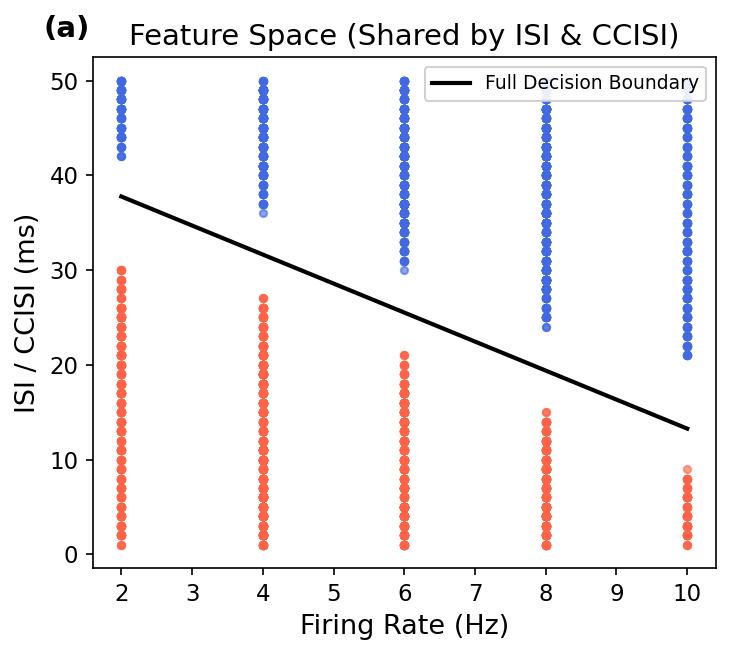

In [2]:
# --- Load dataset (ISI and CCISI share the same feature space) ---
with h5py.File(BASE / "isi/isi_dataset.h5", "r") as f:
    firing_rates = f["firing_rates"][:]
    isis_vals = f["isis"][:]
    labels = f["Y"][:]

# --- Reproduce col_min / col_max from the original data generation ---
# Both ISI and CCISI data generators use np.random.seed(42) with the same
# point-sampling and filtering parameters, so the column extremes are identical.
_rng = np.random.RandomState(42)
_pts = _rng.uniform(-10, 10, (5000, 2))
_slope, _intercept = -0.5, 0.0
_dist = np.abs(_slope * _pts[:, 0] - _pts[:, 1] + _intercept) / np.sqrt(_slope ** 2 + 1)
_pts = _pts[_dist >= 2.5]
col_min, col_max = _pts.min(axis=0), _pts.max(axis=0)

# --- Decision boundary in mapped (FR, ISI) space ---
x_raw = np.linspace(col_min[0], col_max[0], 200)
y_raw = _slope * x_raw + _intercept
fr_boundary = (x_raw - col_min[0]) / (col_max[0] - col_min[0]) * (10 - 2) + 2
isi_boundary = (y_raw - col_min[1]) / (col_max[1] - col_min[1]) * (50 - 1) + 1

'''# --- Rate-only threshold (best vertical split using only firing rate) ---
unique_fr = np.unique(firing_rates)
best_acc, best_thr = 0.0, unique_fr[len(unique_fr) // 2]
for thr in unique_fr:
    acc = max(
        ((firing_rates <= thr) == (labels == 1)).mean(),
        ((firing_rates <= thr) == (labels == 0)).mean(),
    )
    if acc > best_acc:
        best_acc, best_thr = acc, thr'''

# --- Plot ---
fig, ax = plt.subplots(figsize=(5.0, 4.5))

ax.scatter(firing_rates[labels == 0], isis_vals[labels == 0],
           color="royalblue", s=12, alpha=0.6, zorder=2)
ax.scatter(firing_rates[labels == 1], isis_vals[labels == 1],
           color="tomato", s=12, alpha=0.6, zorder=2)

ax.plot(fr_boundary, isi_boundary, color="black", linewidth=2.0,
        label="Full Decision Boundary", zorder=3)

'''ax.axvline(best_thr, color="gray", linestyle="--", linewidth=1.8,
           label="Rate-only Threshold", zorder=3)'''

ax.set_xlabel("Firing Rate (Hz)")
ax.set_ylabel("ISI / CCISI (ms)")
ax.set_title("Feature Space (Shared by ISI & CCISI)")
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)

# subplot label
ax.text(-0.08, 1.04, "(a)", transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
#plt.savefig("feature_space_isi_ccisi.png", dpi=300, bbox_inches="tight")
plt.show()

## ISI & CCISI - Hidden-Layer Spike Rasters (Original vs Perturbed)

Unlike the original paper where perturbation is applied to the **input**, our experiments apply it to the **output of the first hidden layer**.  
Below we pass one example through the trained Tau+Delay model, extract the 100-neuron hidden-layer spike train, and compare:
- **Top row**: original hidden output (temporal structure intact).
- **Bottom row**: the same hidden output after randomising 50 % of each neuron's spikes (f = 0.5).

Only the first 1 000 ms are shown for readability.

d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


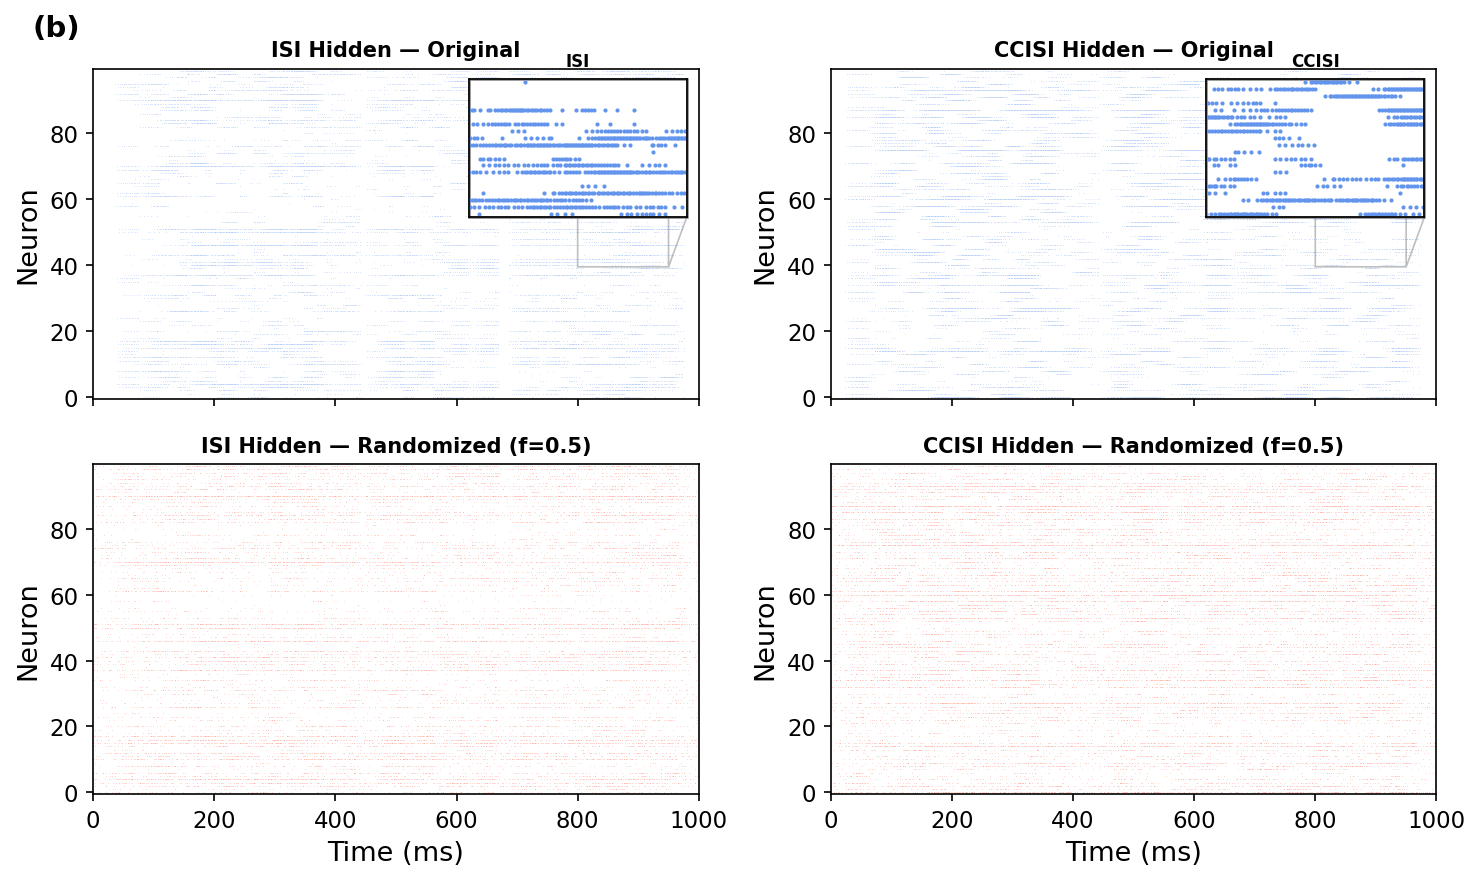

In [3]:
import slayerSNN as snn
from torch import nn

# ===================== SLAYER parameters =====================
MS = 1e-3
_SIM_PARAMS = {"Ts": 1, "tSample": 1000}
_LIF_PARAMS = {
    "type": "SRMALPHA", "theta": 1,
    "tauSr": 1, "tauRho": 1, "tauRef": 1,
    "scaleRef": 2, "scaleRho": 1,
}

_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ===================== Model definitions =====================
def _init_alpha_filter(psp_filter, slayer_obj):
    """Seed the learnable PSP filter with an alpha-function shape."""
    tau = 50 * MS
    Ts = slayer_obj.simulation["Ts"] * MS
    filt_len = psp_filter.weight.shape[-1]
    ak = np.array([t / tau * np.exp(1 - t / tau)
                    for t in np.arange(0, filt_len * Ts, Ts)])
    if np.max(np.abs(ak)) > 0:
        ak /= np.max(np.abs(ak))
    with torch.no_grad():
        psp_filter.weight.data = torch.FloatTensor(
            np.flip(ak).copy()
        ).reshape(psp_filter.weight.shape)


class _ISIDelayNet(nn.Module):
    def __init__(self, num_neurons, num_classes, hidden_units=100, max_delay=15):
        super().__init__()
        sl = snn.layer(_LIF_PARAMS, _SIM_PARAMS)
        self.slayer = sl
        self.fc1 = nn.utils.weight_norm(sl.dense(num_neurons, hidden_units), name="weight")
        self.fc2 = nn.utils.weight_norm(sl.dense(hidden_units, num_classes), name="weight")
        self.psp_filter = sl.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        _init_alpha_filter(self.psp_filter, sl)
        self.delay1 = sl.delay(num_neurons)
        self.delay2 = sl.delay(hidden_units)
        with torch.no_grad():
            self.delay1.delay.data.uniform_(0, max_delay)
            self.delay2.delay.data.uniform_(0, max_delay)

    def first_layer(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        x = x.float().to(_device)
        x = self.delay1(x)
        return self.slayer.spike(self.fc1(self.psp_filter(x)))


class _CCISIDelayNet(nn.Module):
    def __init__(self, num_neurons, num_classes, hidden_units=100, max_delay=10):
        super().__init__()
        sl = snn.layer(_LIF_PARAMS, _SIM_PARAMS)
        self.slayer = sl
        self.fc1 = nn.utils.weight_norm(sl.dense(num_neurons, hidden_units), name="weight")
        self.fc2 = nn.utils.weight_norm(sl.dense(hidden_units, num_classes), name="weight")
        self.psp_filter = sl.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        _init_alpha_filter(self.psp_filter, sl)
        self.delay1 = sl.delay(num_neurons)
        self.delay2 = sl.delay(hidden_units)
        with torch.no_grad():
            self.delay1.delay.data.uniform_(0, max_delay)
            self.delay2.delay.data.uniform_(0, max_delay)

    def first_layer(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        x = x.float().to(_device)
        x = self.delay1(x)
        return self.slayer.spike(self.fc1(self.psp_filter(x)))


# ===================== Perturbation =====================
def _partial_randomize(spike_train: np.ndarray, f: float) -> np.ndarray:
    """Relocate fraction *f* of each neuron's spikes to random empty bins."""
    if f <= 0:
        return spike_train
    out = spike_train.copy()
    num_neurons, T = out.shape
    for n in range(num_neurons):
        st = np.where(spike_train[n] == 1)[0]
        num_move = int(len(st) * f)
        if num_move == 0:
            continue
        chosen = np.random.choice(st, size=num_move, replace=False)
        out[n, chosen] = 0
        placed = 0
        for _ in range(50 * num_move):
            if placed >= num_move:
                break
            t = np.random.randint(0, T)
            if out[n, t] == 0:
                out[n, t] = 1
                placed += 1
    return out


# ===================== Load models & data =====================
# ISI delay model (10 input neurons, max_delay=15)
isi_net = _ISIDelayNet(10, 2, 100, 15).to(_device)
isi_net.load_state_dict(torch.load(BASE / "isi/data/isi_delay_trained.pt", map_location=_device))
isi_net.eval()

# CCISI delay model (20 input neurons, max_delay=10)
ccisi_net = _CCISIDelayNet(20, 2, 100, 10).to(_device)
ccisi_net.load_state_dict(torch.load(BASE / "ccisi/data/ccisi_delay_trained.pt", map_location=_device))
ccisi_net.eval()

# One sample from each dataset
with h5py.File(BASE / "isi/isi_dataset.h5", "r") as fh:
    isi_x = torch.from_numpy(fh["X"][0:1])   # (1, 10, T)
with h5py.File(BASE / "ccisi/ccisi_dataset.h5", "r") as fh:
    ccisi_x = torch.from_numpy(fh["X"][0:1])  # (1, 20, T)

# Forward through first layer to get hidden spikes
with torch.no_grad():
    isi_hidden = isi_net.first_layer(isi_x)[0, :, 0, 0, :].cpu().numpy()    # (100, T)
    ccisi_hidden = ccisi_net.first_layer(ccisi_x)[0, :, 0, 0, :].cpu().numpy()

# Perturbed versions (f = 0.5)
np.random.seed(0)
isi_perturbed = _partial_randomize(isi_hidden, f=0.5)
ccisi_perturbed = _partial_randomize(ccisi_hidden, f=0.5)

# ===================== Plot =====================
SHOW_T = 1000  # first 1000 ms

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

panels = [
    (axes[0, 0], isi_hidden[:, :SHOW_T],     "ISI Hidden — Original",        "cornflowerblue"),
    (axes[0, 1], ccisi_hidden[:, :SHOW_T],    "CCISI Hidden — Original",      "cornflowerblue"),
    (axes[1, 0], isi_perturbed[:, :SHOW_T],   "ISI Hidden — Randomized (f=0.5)",  "tomato"),
    (axes[1, 1], ccisi_perturbed[:, :SHOW_T], "CCISI Hidden — Randomized (f=0.5)","tomato"),
]

for ax, spikes, title, color in panels:
    neurons, times = np.where(spikes == 1)
    ax.scatter(times, neurons, s=0.15, c=color, marker=".", linewidths=0, rasterized=True)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylim(-0.5, 99.5)
    ax.set_xlim(0, SHOW_T)
    ax.set_ylabel("Neuron")

# Add zoom insets on top-row panels
for ax, spikes, label in [
    (axes[0, 0], isi_hidden[:, :SHOW_T], "ISI"),
    (axes[0, 1], ccisi_hidden[:, :SHOW_T], "CCISI"),
]:
    # Pick a region with visible spikes for the inset
    region_t = (800, 950)
    region_n = (40, 60)
    inset = ax.inset_axes([0.62, 0.55, 0.36, 0.42])
    sub = spikes[region_n[0]:region_n[1], region_t[0]:region_t[1]]
    ns, ts = np.where(sub == 1)
    inset.scatter(ts + region_t[0], ns + region_n[0],
                  s=4, c="cornflowerblue", marker="o", linewidths=0)
    inset.set_xlim(region_t)
    inset.set_ylim(region_n[0] - 0.5, region_n[1] - 0.5)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_title(label, fontsize=8, fontweight="bold")
    inset.patch.set_edgecolor("gray")
    inset.patch.set_linewidth(1.2)
    ax.indicate_inset_zoom(inset, edgecolor="gray", linewidth=0.8)

for ax in axes[1, :]:
    ax.set_xlabel("Time (ms)")

# subplot label
axes[0, 0].text(-0.10, 1.10, "(b)", transform=axes[0, 0].transAxes,
                fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()

## ISI & CCISI - Accuracy vs Hidden-Layer Perturbation

Both ISI and CCISI tasks encode class information purely in spike timing.  
This plot shows how accuracy degrades as hidden-layer temporal structure is progressively destroyed.  
The dashed **FR Only Baseline** line marks the accuracy of a rate-only model (f = 1 on the worse-performing variant), giving a lower-bound reference.

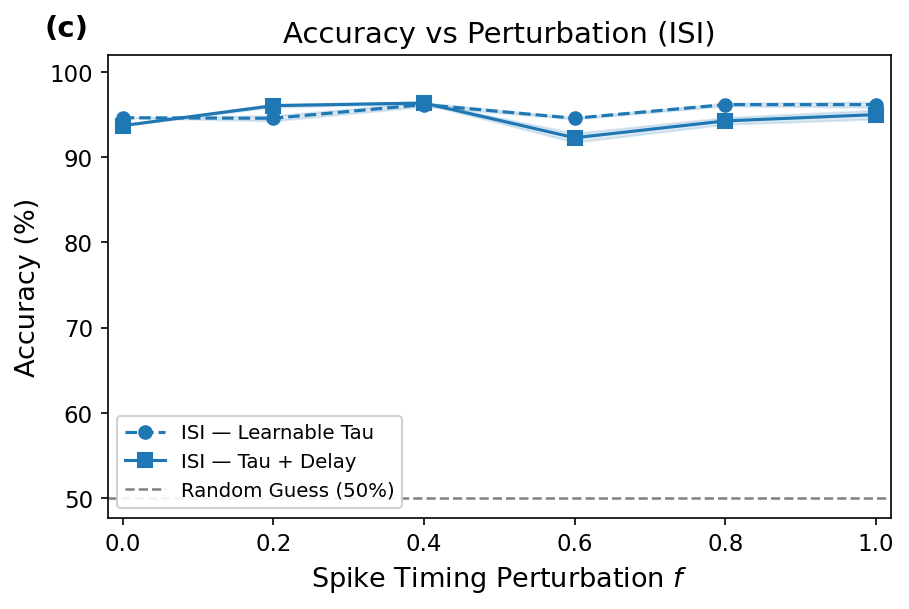

In [4]:
def load_results(path: pathlib.Path) -> dict:
    """Load a perturbation results JSON and return (f_values, means, stds)."""
    with open(path) as fh:
        raw = json.load(fh)
    f_vals = sorted(float(k) for k in raw)
    means = np.array([raw[str(f) if str(f) in raw else f"{f:.1f}"]["mean"] for f in f_vals]) * 100
    stds = np.array([raw[str(f) if str(f) in raw else f"{f:.1f}"]["std"] for f in f_vals]) * 100
    return f_vals, means, stds


# --- load ISI results ---
isi_tau_f, isi_tau_mean, isi_tau_std = load_results(BASE / "isi/log/isi_tau_hidden_perturbation_results.json")
isi_del_f, isi_del_mean, isi_del_std = load_results(BASE / "isi/log/isi_delay_hidden_perturbation_results.json")

# --- load CCISI results ---
cc_tau_f, cc_tau_mean, cc_tau_std = load_results(BASE / "ccisi/log/ccisi_tau_hidden_perturbation_results.json")
cc_del_f, cc_del_mean, cc_del_std = load_results(BASE / "ccisi/log/ccisi_delay_hidden_perturbation_results.json")

# --- FR-only baseline: worst f=1 accuracy across all four curves ---
#fr_baseline = min(isi_tau_mean[-1], isi_del_mean[-1], cc_tau_mean[-1], cc_del_mean[-1])
guess_baseline = 50

# --- colours matching the reference image ---
BLUE = "#1f77b4"
RED = "#d62728"

fig, ax = plt.subplots(figsize=(6.2, 4.2))

# ISI curves (blue)
ax.plot(isi_tau_f, isi_tau_mean, "o--", color=BLUE, markersize=6, label="ISI — Learnable Tau")
ax.fill_between(isi_tau_f, isi_tau_mean - isi_tau_std, isi_tau_mean + isi_tau_std, color=BLUE, alpha=0.15)

ax.plot(isi_del_f, isi_del_mean, "s-", color=BLUE, markersize=7, label="ISI — Tau + Delay")
ax.fill_between(isi_del_f, isi_del_mean - isi_del_std, isi_del_mean + isi_del_std, color=BLUE, alpha=0.15)

# CCISI curves (red)
#ax.plot(cc_tau_f, cc_tau_mean, "o--", color=RED, markersize=6, label="CCISI — Learnable Tau")
#ax.fill_between(cc_tau_f, cc_tau_mean - cc_tau_std, cc_tau_mean + cc_tau_std, color=RED, alpha=0.15)

#ax.plot(cc_del_f, cc_del_mean, "s-", color=RED, markersize=7, label="CCISI — Tau + Delay")
#ax.fill_between(cc_del_f, cc_del_mean - cc_del_std, cc_del_mean + cc_del_std, color=RED, alpha=0.15)

# FR-only baseline
#ax.axhline(fr_baseline, color="gray", linestyle="--", linewidth=1.2, label="FR Only Baseline")

# Random guess baseline
ax.axhline(guess_baseline, color="gray", linestyle="--", linewidth=1.2, label="Random Guess (50%)")

# --- axes & labels ---
ax.set_xlabel("Spike Timing Perturbation $f$")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Perturbation (ISI)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(None, 102)
ax.legend(loc="lower left", framealpha=0.9)

# subplot label like the reference image
ax.text(-0.08, 1.04, "(c)", transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
#plt.savefig("isi_ccisi_hidden_perturbation.png", dpi=300, bbox_inches="tight")
plt.show()

## Coincidence - Example Spike Rasters

The coincidence task has 60 neurons split into three groups of 20. Each class is defined by which **pair** of groups fires synchronously (coincides), while the third group fires in anti-phase.  
- **Class A**: groups 1 & 2 coincide, group 3 anti-phase  
- **Class B**: groups 1 & 3 coincide, group 2 anti-phase  
- **Class C**: groups 2 & 3 coincide, group 1 anti-phase  

The parameter **λ** controls the overlap between coincident and anti-phase windows: at λ = 0 groups fire in clearly separated windows; as λ → 1 the windows overlap and the task becomes harder.

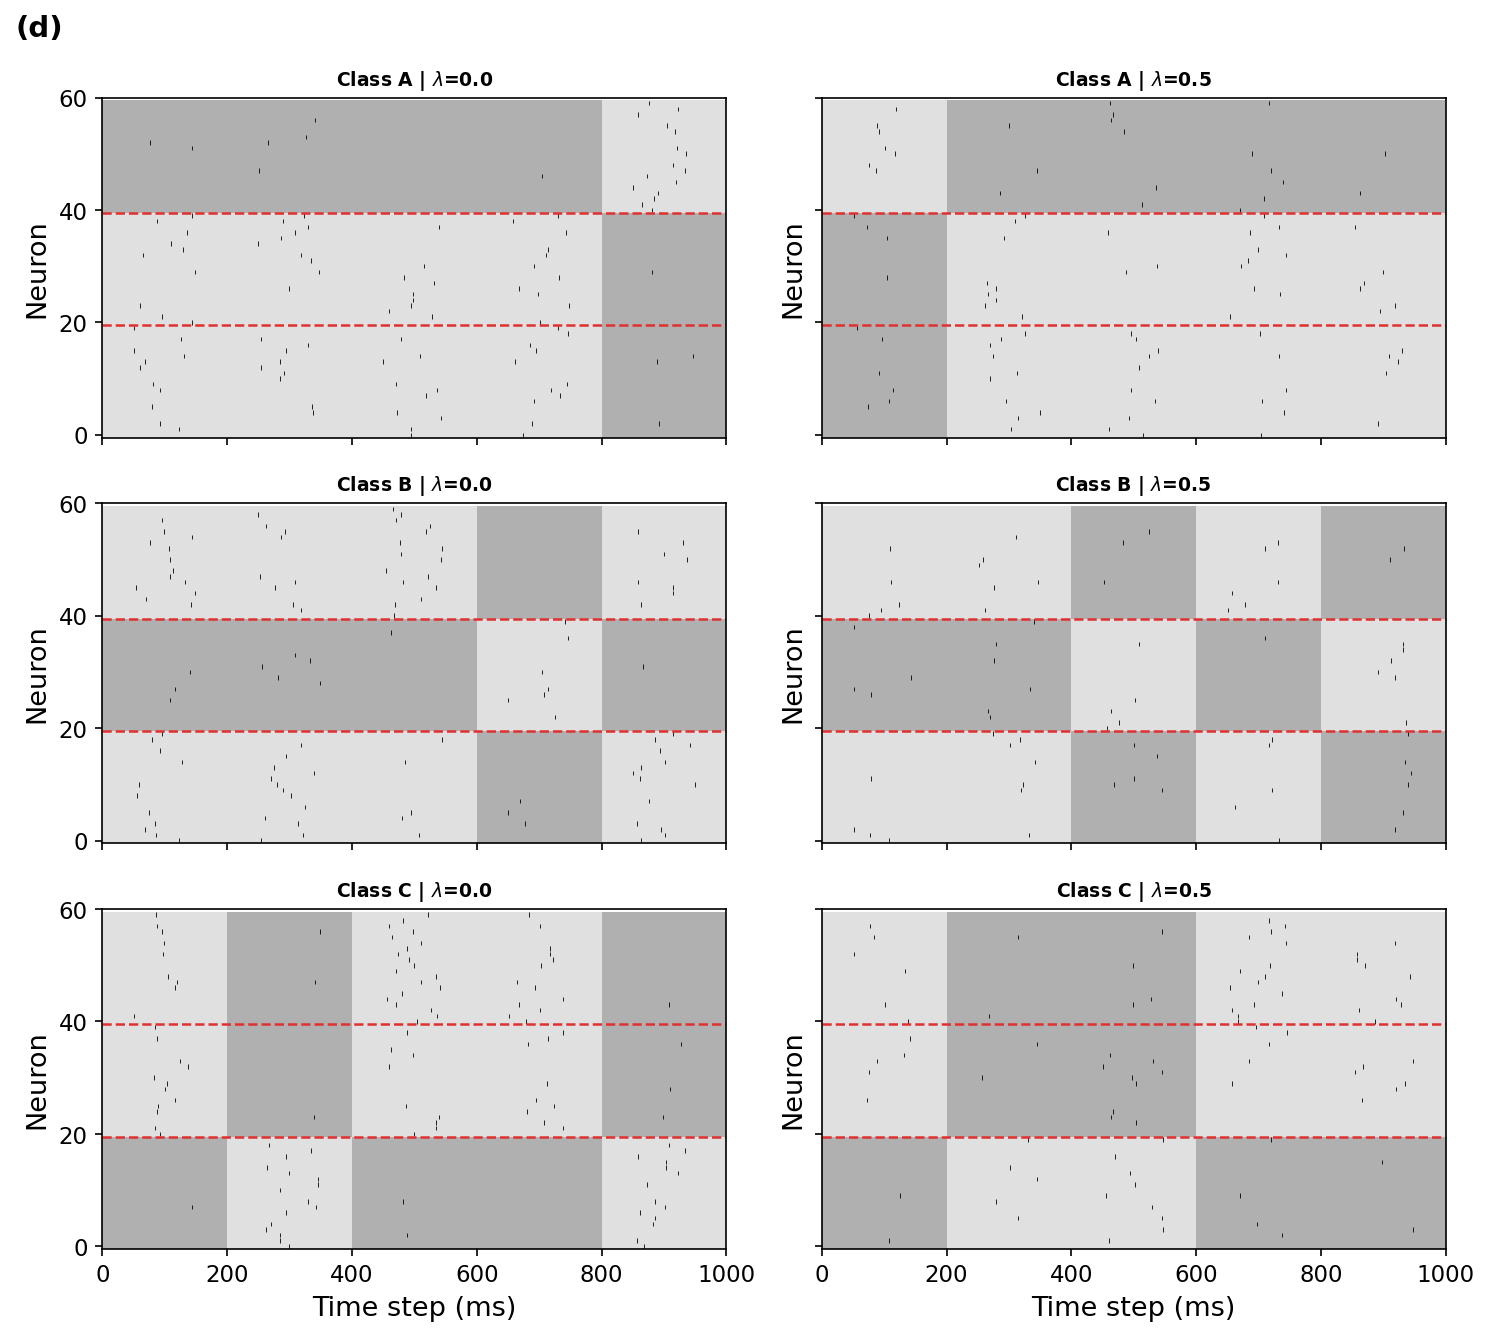

In [5]:
# ---------- coincidence constants ----------
COIN_DIR = BASE / "coincidence"
CLASS_NAMES = ("A", "B", "C")
GROUP_SIZE = 20
GROUP_BOUNDARIES = [GROUP_SIZE, GROUP_SIZE * 2]
WINDOW_SIZE = 200
CLASS_COINCIDENT_PAIR = {"A": (0, 1), "B": (0, 2), "C": (1, 2)}
COLOR_ON = "#e0e0e0"
COLOR_OFF = "#b0b0b0"
BOUNDARY_COLOR = "#e03030"
SPIKE_COLOR = "black"
DISPLAY_LAMBDAS = [0.0, 0.5]


def _load_coin_data(lam_prime: float) -> dict:
    """Load a coincidence .pt file for a given lambda value."""
    fname = COIN_DIR / f"coin_data_lam{int(round(lam_prime * 10)):02d}.pt"
    return torch.load(fname, weights_only=False)


def _pick_example(data: dict, class_label: int, sample_index: int = 0) -> np.ndarray:
    """Return one spike train for the requested class."""
    indices = np.where(np.array(data["Y"]) == class_label)[0]
    return np.array(data["X"][indices[sample_index]])


def _infer_window_states(spike_train: np.ndarray, class_name: str) -> np.ndarray:
    """Infer per-window ON/OFF state from spike counts."""
    n_timesteps = spike_train.shape[1]
    n_windows = n_timesteps // WINDOW_SIZE
    pair = CLASS_COINCIDENT_PAIR[class_name]
    anti = ({0, 1, 2} - set(pair)).pop()
    group_slices = [
        slice(0, GROUP_SIZE),
        slice(GROUP_SIZE, GROUP_SIZE * 2),
        slice(GROUP_SIZE * 2, GROUP_SIZE * 3),
    ]
    states = np.zeros(n_windows, dtype=bool)
    for w in range(n_windows):
        t0, t1 = w * WINDOW_SIZE, (w + 1) * WINDOW_SIZE
        pair_count = (
            spike_train[group_slices[pair[0]], t0:t1].sum()
            + spike_train[group_slices[pair[1]], t0:t1].sum()
        )
        anti_count = spike_train[group_slices[anti], t0:t1].sum()
        states[w] = pair_count / 2 > anti_count
    return states


# ---------- plot ----------
n_rows, n_cols = len(CLASS_NAMES), len(DISPLAY_LAMBDAS)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 3 * n_rows),
    sharex=True, sharey=True,
)

for col, lam_prime in enumerate(DISPLAY_LAMBDAS):
    data = _load_coin_data(lam_prime)
    for row, class_name in enumerate(CLASS_NAMES):
        ax = axes[row, col]
        spike_train = _pick_example(data, class_label=row)
        n_neurons, n_timesteps = spike_train.shape

        # --- background shading (ON / OFF windows per group) ---
        ax.set_facecolor("white")
        pair = CLASS_COINCIDENT_PAIR[class_name]
        window_states = _infer_window_states(spike_train, class_name)
        group_edges = [0] + GROUP_BOUNDARIES + [n_neurons]
        n_windows = n_timesteps // WINDOW_SIZE

        for w in range(n_windows):
            x0, x1 = w * WINDOW_SIZE, (w + 1) * WINDOW_SIZE
            for g_idx, (y_lo, y_hi) in enumerate(zip(group_edges[:-1], group_edges[1:])):
                is_coincident = g_idx in pair
                if window_states[w]:
                    color = COLOR_ON if is_coincident else COLOR_OFF
                else:
                    color = COLOR_OFF if is_coincident else COLOR_ON
                ax.fill_between([x0, x1], y_lo - 0.5, y_hi - 0.5,
                                facecolor=color, edgecolor="none", zorder=0)

        # --- spike raster ---
        for neuron_idx in range(n_neurons):
            spike_times = np.where(spike_train[neuron_idx] == 1)[0]
            ax.vlines(spike_times, neuron_idx - 0.4, neuron_idx + 0.4,
                      color=SPIKE_COLOR, linewidth=0.4, zorder=1)

        # --- group boundary lines ---
        for boundary in GROUP_BOUNDARIES:
            ax.axhline(y=boundary - 0.5, color=BOUNDARY_COLOR,
                       linewidth=1.2, linestyle="--", zorder=2)

        ax.set_title(f"Class {class_name} | $\\lambda$={lam_prime:.1f}",
                     fontsize=9, fontweight="bold")
        ax.set_ylim(-0.5, n_neurons - 0.5)
        ax.set_xlim(0, n_timesteps)
        ax.set_ylabel("Neuron")
        ax.set_yticks([0, 20, 40, 60])

for ax in axes[-1, :]:
    ax.set_xlabel("Time step (ms)")

# subplot label
axes[0, 0].text(-0.14, 1.18, "(d)", transform=axes[0, 0].transAxes,
                fontsize=14, fontweight="bold")

fig.tight_layout()
#plt.savefig("coincidence_raster_examples.png", dpi=300, bbox_inches="tight")
plt.show()

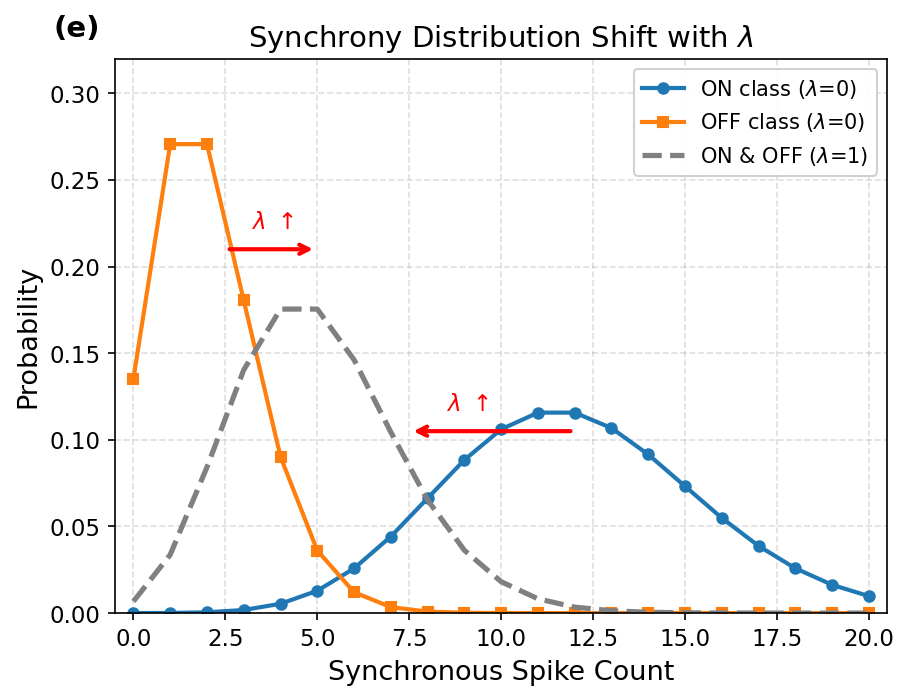

In [6]:
from scipy.stats import poisson

# ---------- ON / OFF distribution parameters ----------
# At lambda=0: ON mean=12, OFF mean=2 (well separated)
# At lambda=1: both mean=5 (fully overlapped, task impossible)
MAX_K = GROUP_SIZE  # 20

k_vals = np.arange(0, MAX_K + 1)

# lambda = 0: ON and OFF are clearly separated
on_mu_0 = (1 - 0) * 12 + 0 * 5   # 12
off_mu_0 = (1 - 0) * 2 + 0 * 5   # 2
on_pmf_0 = poisson.pmf(k_vals, on_mu_0)
off_pmf_0 = poisson.pmf(k_vals, off_mu_0)
on_pmf_0 /= on_pmf_0.sum()
off_pmf_0 /= off_pmf_0.sum()

# lambda = 1: both converge to the same distribution
merged_mu = 5.0
merged_pmf = poisson.pmf(k_vals, merged_mu)
merged_pmf /= merged_pmf.sum()

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(6.2, 4.8))

ax.plot(k_vals, on_pmf_0, "o-", color="#1f77b4", markersize=5, linewidth=2,
        label=r"ON class ($\lambda$=0)")
ax.plot(k_vals, off_pmf_0, "s-", color="#ff7f0e", markersize=5, linewidth=2,
        label=r"OFF class ($\lambda$=0)")
ax.plot(k_vals, merged_pmf, "--", color="gray", linewidth=2.5,
        label=r"ON & OFF ($\lambda$=1)")

# --- red arrows showing distribution shift as lambda increases ---
ax.annotate("", xy=(5.0, 0.21), xytext=(2.5, 0.21),
            arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.text(3.2, 0.222, r"$\lambda$ $\uparrow$", color="red", fontsize=11, fontweight="bold")

ax.annotate("", xy=(7.5, 0.105), xytext=(12.0, 0.105),
            arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.text(8.5, 0.117, r"$\lambda$ $\uparrow$", color="red", fontsize=11, fontweight="bold")

ax.set_xlabel("Synchronous Spike Count")
ax.set_ylabel("Probability")
ax.set_title(r"Synchrony Distribution Shift with $\lambda$")
ax.set_xlim(-0.5, MAX_K + 0.5)
ax.set_ylim(0, 0.32)
ax.legend(loc="upper right", framealpha=0.9, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)

# subplot label
ax.text(-0.08, 1.04, "(e)", transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
#lt.savefig("coincidence_distribution_shift.png", dpi=300, bbox_inches="tight")
plt.show()

## Coincidence - Tau vs Tau+Delay Accuracy

Test accuracy of the two model variants (Learnable Tau and Tau + Delay) across increasing synchrony overlap λ.  
At λ = 0 the ON/OFF distributions are well separated and the task is easy; as λ → 1 the distributions merge and accuracy approaches random chance (33.3% for 3 classes).

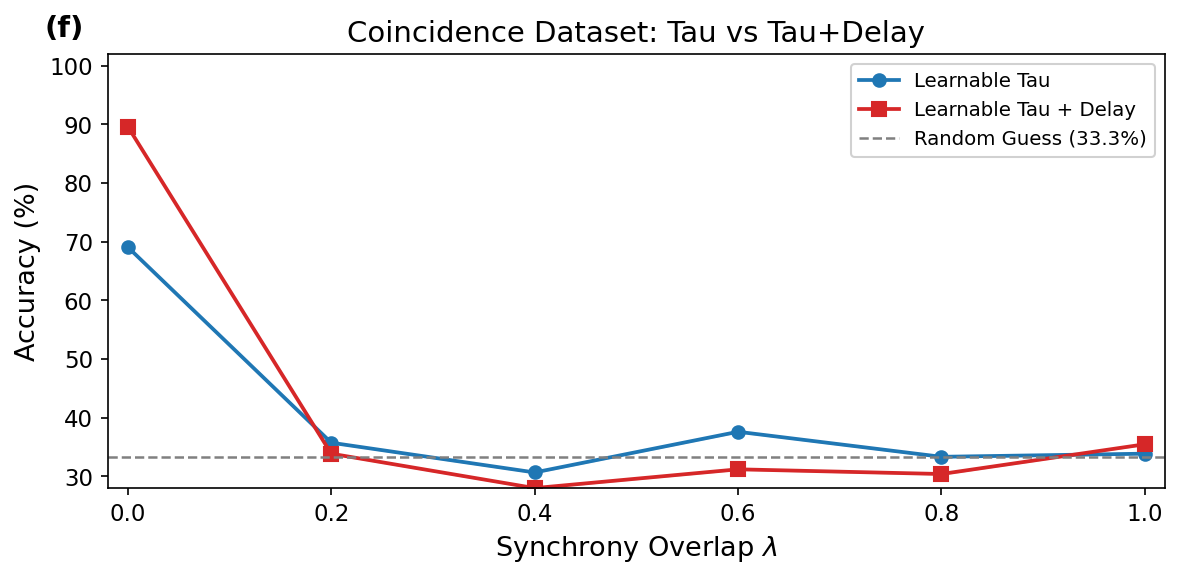

In [7]:
# --- Load coincidence perturbation results (f=0 slice = clean accuracy) ---
COIN_LOG = BASE / "coincidence/log"

with open(COIN_LOG / "coin_tau_hidden_perturbation_results.json") as fh:
    coin_tau_raw = json.load(fh)
with open(COIN_LOG / "coin_delay_hidden_perturbation_results.json") as fh:
    coin_del_raw = json.load(fh)

# Extract f=0.0 (clean) accuracy at each lambda
lam_vals = sorted(float(k) for k in coin_tau_raw)
tau_means = np.array([coin_tau_raw[f"{lam:.1f}"]["0.0"]["mean"] for lam in lam_vals]) * 100
tau_stds = np.array([coin_tau_raw[f"{lam:.1f}"]["0.0"]["std"] for lam in lam_vals]) * 100
del_means = np.array([coin_del_raw[f"{lam:.1f}"]["0.0"]["mean"] for lam in lam_vals]) * 100
del_stds = np.array([coin_del_raw[f"{lam:.1f}"]["0.0"]["std"] for lam in lam_vals]) * 100

# --- Plot ---
BLUE = "#1f77b4"
RED = "#d62728"

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(lam_vals, tau_means, "o-", color=BLUE, markersize=6, linewidth=1.8,
        label="Learnable Tau")
ax.fill_between(lam_vals, tau_means - tau_stds, tau_means + tau_stds,
                color=BLUE, alpha=0.15)

ax.plot(lam_vals, del_means, "s-", color=RED, markersize=7, linewidth=1.8,
        label="Learnable Tau + Delay")
ax.fill_between(lam_vals, del_means - del_stds, del_means + del_stds,
                color=RED, alpha=0.15)

ax.axhline(100 / 3, color="gray", linestyle="--", linewidth=1.2,
           label="Random Guess (33.3%)")

ax.set_xlabel(r"Synchrony Overlap $\lambda$")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Coincidence Dataset: Tau vs Tau+Delay")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(28, 102)
ax.legend(loc="upper right", framealpha=0.9)

# subplot label
ax.text(-0.06, 1.04, "(f)", transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
#plt.savefig("coincidence_accuracy_vs_lambda.png", dpi=300, bbox_inches="tight")
plt.show()